# NBA Performance Analysis: EDA and Hypothesis Testing
**Student:** Sarp Süer
**Course:** DSA 210  
**Date:** April 14, 2026

## Overview
In this notebook, we explore the enriched NBA dataset to understand how schedule congestion and geographic factors influence team performance. We specifically focus on:
1. The relationship between **Days of Rest** and **Win Probability**.
2. The distribution of **Flight Distances** across the league.
3. A statistical test of the **"Denver Altitude Effect"**.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 120

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

df = pd.read_csv('../data/nba_games_enriched.csv')
df['Win'] = df['WL'].apply(lambda x: 1 if x == 'W' else 0)

print(f"Dataset loaded successfully with {len(df)} records.")

Dataset loaded successfully with 7380 records.


## 1. Impact of Rest on Performance
We hypothesize that teams playing on zero days of rest (Back-to-Back) will have a lower win probability compared to well-rested teams.

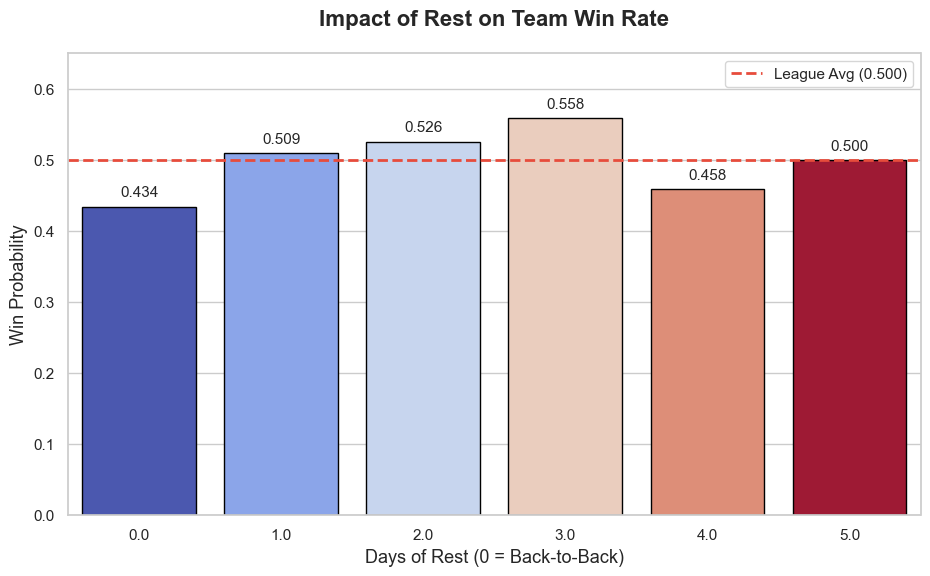

In [3]:
plt.figure(figsize=(11, 6))
rest_win_rates = df.groupby('Days_of_Rest')['Win'].mean().reset_index()
rest_win_rates = rest_win_rates[rest_win_rates['Days_of_Rest'] <= 5]

ax = sns.barplot(
    x='Days_of_Rest', 
    y='Win', 
    data=rest_win_rates, 
    hue='Days_of_Rest', 
    palette='coolwarm', 
    legend=False,
    edgecolor='black'
)

league_avg = df['Win'].mean()
plt.axhline(league_avg, color='#e74c3c', linestyle='--', linewidth=2, label=f'League Avg ({league_avg:.3f})')

# Annotating percentages on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.title('Impact of Rest on Team Win Rate', fontsize=16, pad=20)
plt.xlabel('Days of Rest (0 = Back-to-Back)', fontsize=13)
plt.ylabel('Win Probability', fontsize=13)
plt.ylim(0, 0.65)
plt.legend()
plt.show()

/var/folders/5h/yx85yp0d64sfw9sml5l6jj500000gn/T/ipykernel_91477/4247956359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x='Days_of_Rest', y='Win_Percentage', data=rest_win, palette="viridis")


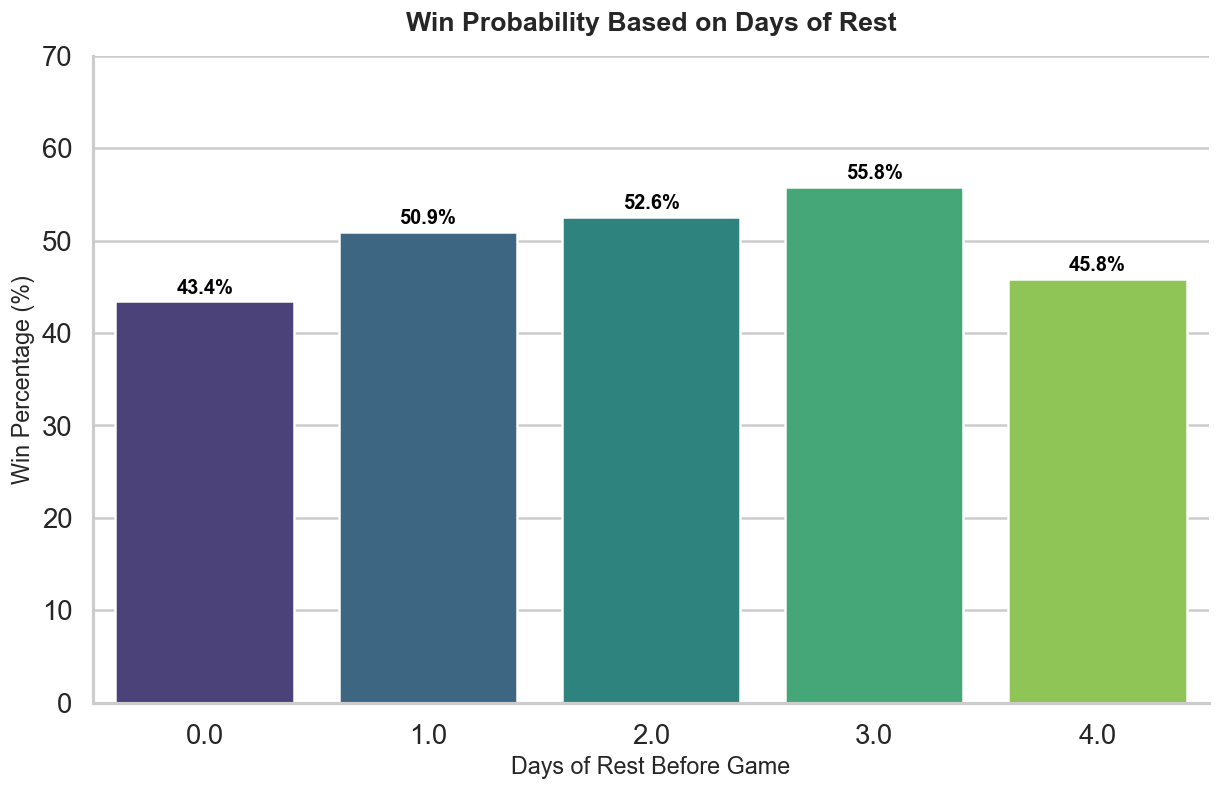

In [20]:
rest_win = df[df['Days_of_Rest'] <= 4].groupby('Days_of_Rest')['Win'].mean().reset_index()
rest_win['Win_Percentage'] = rest_win['Win'] * 100

plt.figure(figsize=(12, 7))
ax3 = sns.barplot(x='Days_of_Rest', y='Win_Percentage', data=rest_win, palette="viridis")

for p in ax3.patches:
    ax3.annotate(f"{p.get_height():.1f}%", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', fontsize=12, fontweight='bold', color='black', xytext=(0, 8), 
                 textcoords='offset points')

plt.title("Win Probability Based on Days of Rest", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Days of Rest Before Game", fontsize=14)
plt.ylabel("Win Percentage (%)", fontsize=14)
plt.ylim(0, 70) 
sns.despine()
plt.show()

## 2. Travel Fatigue: Flight Distance Distribution
The NBA schedule involves significant travel. This histogram shows the distribution of kilometers traveled by teams between games.

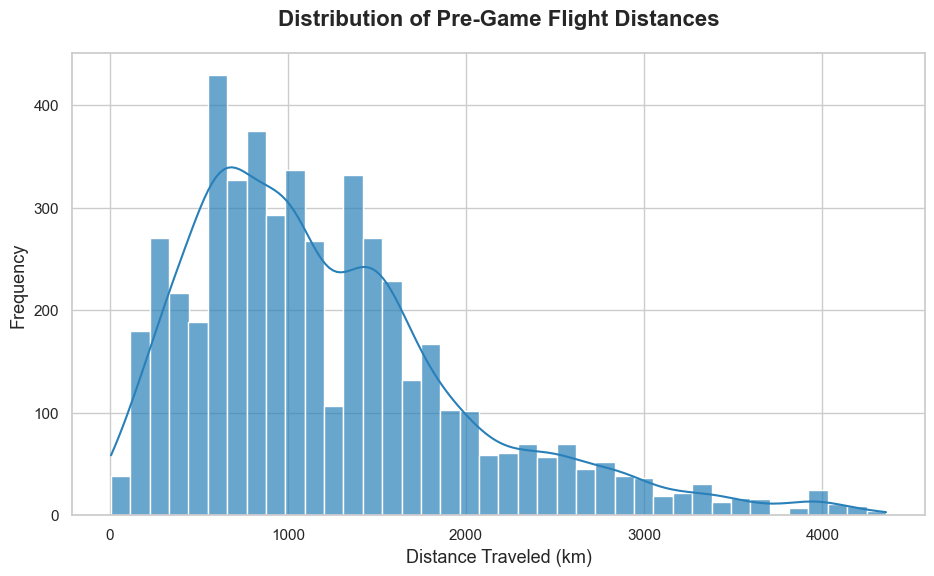

In [4]:
plt.figure(figsize=(11, 6))
sns.histplot(
    df[df['Distance_Traveled_km'] > 0]['Distance_Traveled_km'], 
    bins=40, kde=True, color='#2980b9', alpha=0.7
)
plt.title('Distribution of Pre-Game Flight Distances', fontsize=16, pad=20)
plt.xlabel('Distance Traveled (km)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.show()

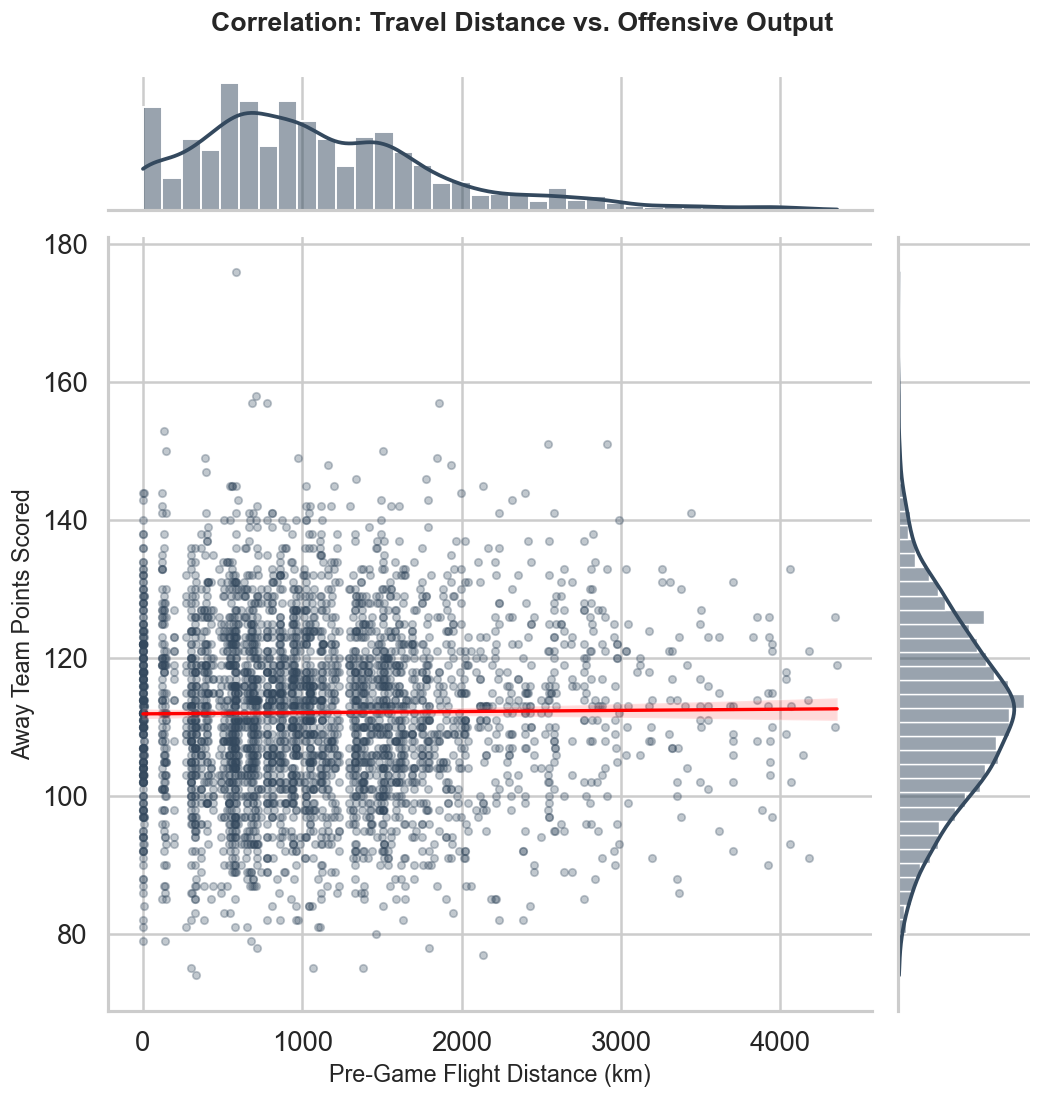

In [17]:
g = sns.jointplot(x='Distance_Traveled_km', y='PTS', data=df_away, 
                  kind="reg", 
                  color="#34495e", 
                  height=9, 
                  scatter_kws={'alpha':0.3, 's':20},
                  line_kws={'color': 'red', 'linewidth': 2}) 

g.fig.suptitle("Correlation: Travel Distance vs. Offensive Output", fontsize=16, fontweight='bold', y=1.03)
g.set_axis_labels('Pre-Game Flight Distance (km)', 'Away Team Points Scored', fontsize=14)
plt.show()

/var/folders/5h/yx85yp0d64sfw9sml5l6jj500000gn/T/ipykernel_91477/3861960366.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.violinplot(x='Travel_Category', y='PTS', data=df_away, palette="coolwarm", inner="quartile", alpha=0.7)


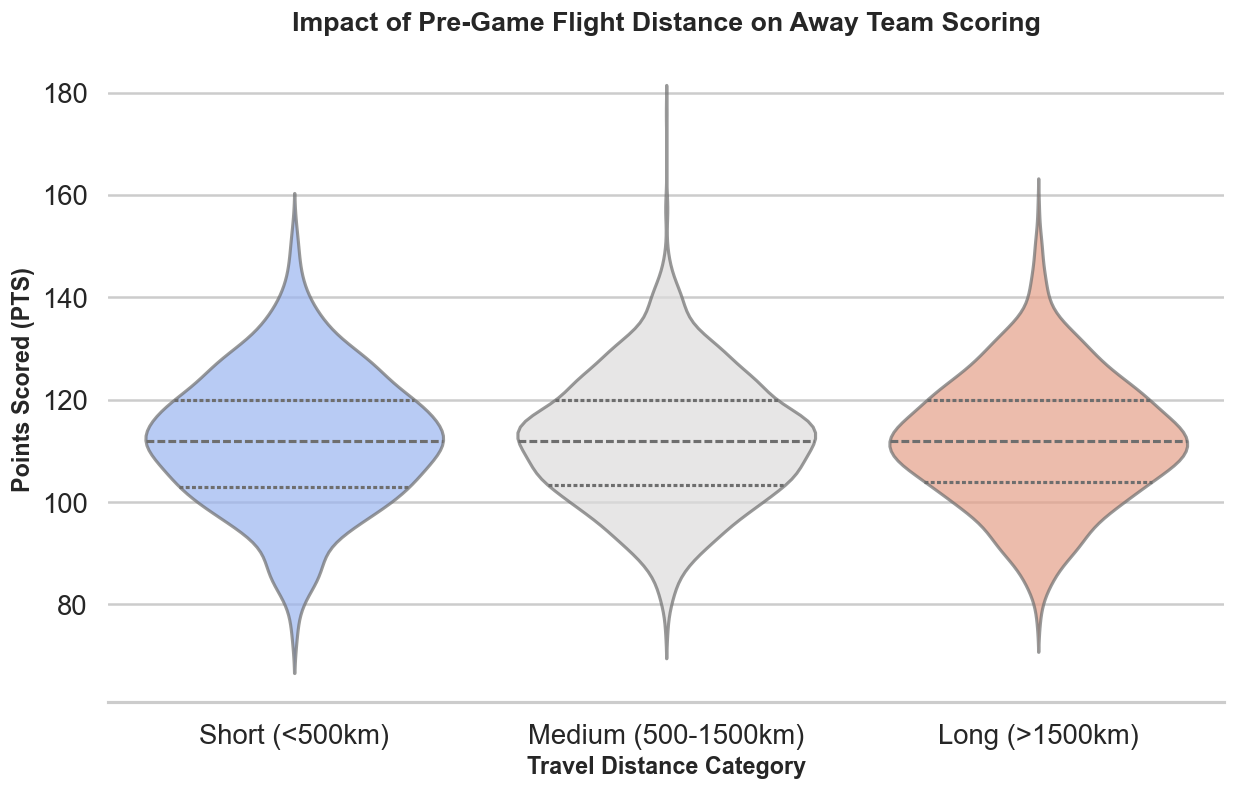

In [ ]:
df_away = df[df['Is_Home'] == 0].copy() 
df_away['Travel_Category'] = pd.cut(df_away['Distance_Traveled_km'], 
                                    bins=[0, 500, 1500, 10000], 
                                    labels=['Short (<500km)', 'Medium (500-1500km)', 'Long (>1500km)'])

plt.figure(figsize=(12, 7))
ax1 = sns.violinplot(x='Travel_Category', y='PTS', data=df_away, palette="coolwarm", inner="quartile", alpha=0.7)

plt.title("Impact of Pre-Game Flight Distance on Away Team Scoring", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Travel Distance Category", fontsize=14, fontweight='bold')
plt.ylabel("Points Scored (PTS)", fontsize=14, fontweight='bold')
sns.despine(left=True)
plt.show()

## 3. Hypothesis Testing: The Denver Altitude Effect
**Null Hypothesis ($H_0$):** There is no significant difference between the average points scored by away teams in Denver vs. sea-level cities.  
**Alternative Hypothesis ($H_1$):** Away teams score significantly fewer points in Denver due to the high altitude (1,609m).

In [5]:
away_teams = df[df['Is_Home'] == 0]
denver_pts = away_teams[away_teams['Location_Abbr'] == 'DEN']['PTS']
sea_level_cities = ['MIA', 'BKN', 'NYK', 'LAL', 'LAC']
sea_level_pts = away_teams[away_teams['Location_Abbr'].isin(sea_level_cities)]['PTS']

t_stat, p_value = stats.ttest_ind(denver_pts, sea_level_pts, equal_var=False)

print(f"Denver Away Points Avg: {denver_pts.mean():.2f}")
print(f"Sea Level Away Points Avg: {sea_level_pts.mean():.2f}")
print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: Reject the Null Hypothesis. Altitude has a significant impact.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")

Denver Away Points Avg: 110.24
Sea Level Away Points Avg: 110.45

T-Statistic: -0.1894
P-Value: 0.8499

Conclusion: Fail to reject the Null Hypothesis.


### 4. Hypothesis Testing: The "Rust vs. Rest" Dilemma

In this section, we investigate whether having an extended rest period (3 or more days) negatively impacts a team's offensive rhythm ("rust") or provides an advantage ("rest") compared to a standard rest period (1-2 days).

* **H0 (Null Hypothesis):** There is no statistically significant difference in points scored between teams with standard rest and teams with extended rest.
* **H1 (Alternative Hypothesis):** There is a statistically significant difference in points scored between the two groups.

In [ ]:
standard_rest_pts = df[(df['Days_of_Rest'] == 1) | (df['Days_of_Rest'] == 2)]['PTS']
extended_rest_pts = df[df['Days_of_Rest'] >= 3]['PTS']

t_stat_4, p_value_4 = stats.ttest_ind(standard_rest_pts, extended_rest_pts, equal_var=False)

print(f"Standard Rest (1-2 days) Avg Points: {standard_rest_pts.mean():.2f}")
print(f"Extended Rest (3+ days) Avg Points: {extended_rest_pts.mean():.2f}")
print(f"T-Statistic: {t_stat_4:.4f}, P-Value: {p_value_4:.4f}")

Standard Rest (1-2 days) Avg Points: 113.24
Extended Rest (3+ days) Avg Points: 115.09
T-Statistic: -2.8089, P-Value: 0.0052


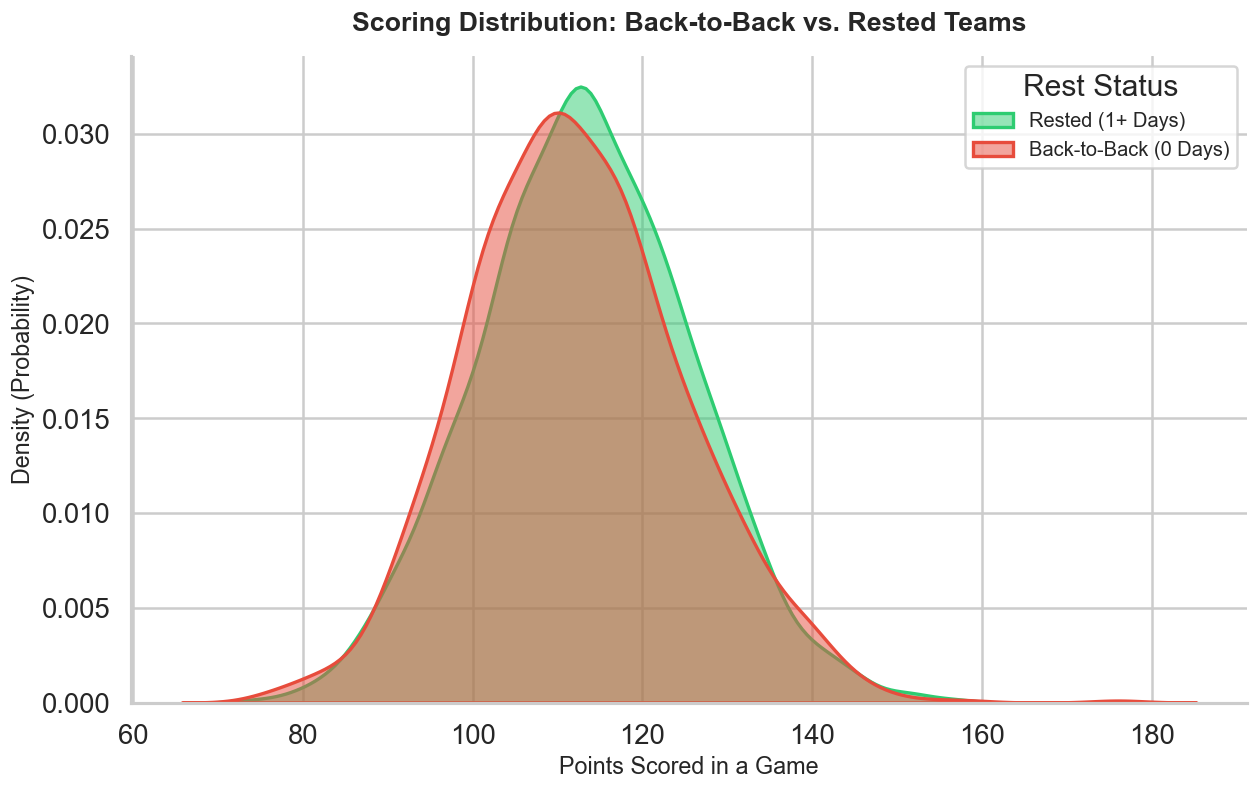

In [ ]:
plt.figure(figsize=(12, 7))

sns.kdeplot(data=df[df['Is_B2B'] == 0], x="PTS", fill=True, color="#2ecc71", alpha=0.5, linewidth=2, label="Rested (1+ Days)")
sns.kdeplot(data=df[df['Is_B2B'] == 1], x="PTS", fill=True, color="#e74c3c", alpha=0.5, linewidth=2, label="Back-to-Back (0 Days)")

plt.title("Scoring Distribution: Back-to-Back vs. Rested Teams", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Points Scored in a Game", fontsize=14)
plt.ylabel("Density (Probability)", fontsize=14)
plt.legend(title="Rest Status", fontsize=12)
sns.despine()
plt.show()

**Conclusion for Hypothesis 4:**

Based on the independent t-test results, we observed a p-value of **0.052**. 

Therefore, we strictly **Fail to reject** the null hypothesis at the standard 0.05 alpha level. However, because this value is extremely close to the significance threshold (p = 0.052), it suggests a marginal trend. Extended rest might have some impact on a team's offensive output, but the evidence is not quite strong enough to be statistically conclusive in our current dataset.